In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Load the datasets ---
try:
    env_sizes_df = pd.read_csv("results_env_sizes.csv")
    model_sizes_df = pd.read_csv("results.csv")
except FileNotFoundError as e:
    print(f"Error: {e}. Please make sure the CSV files are in the correct directory.")
    # Create empty dataframes to prevent further errors
    env_sizes_df = pd.DataFrame()
    model_sizes_df = pd.DataFrame()

# --- Filter for Centralized runs only ---
centralized_env_sizes = env_sizes_df[env_sizes_df['run_name'] == 'Centralized'].copy()
centralized_model_sizes = model_sizes_df[model_sizes_df['run_name'] == 'Centralized'].copy()

# Set a nice style for the plots
plt.style.use('seaborn-v0_8-whitegrid')

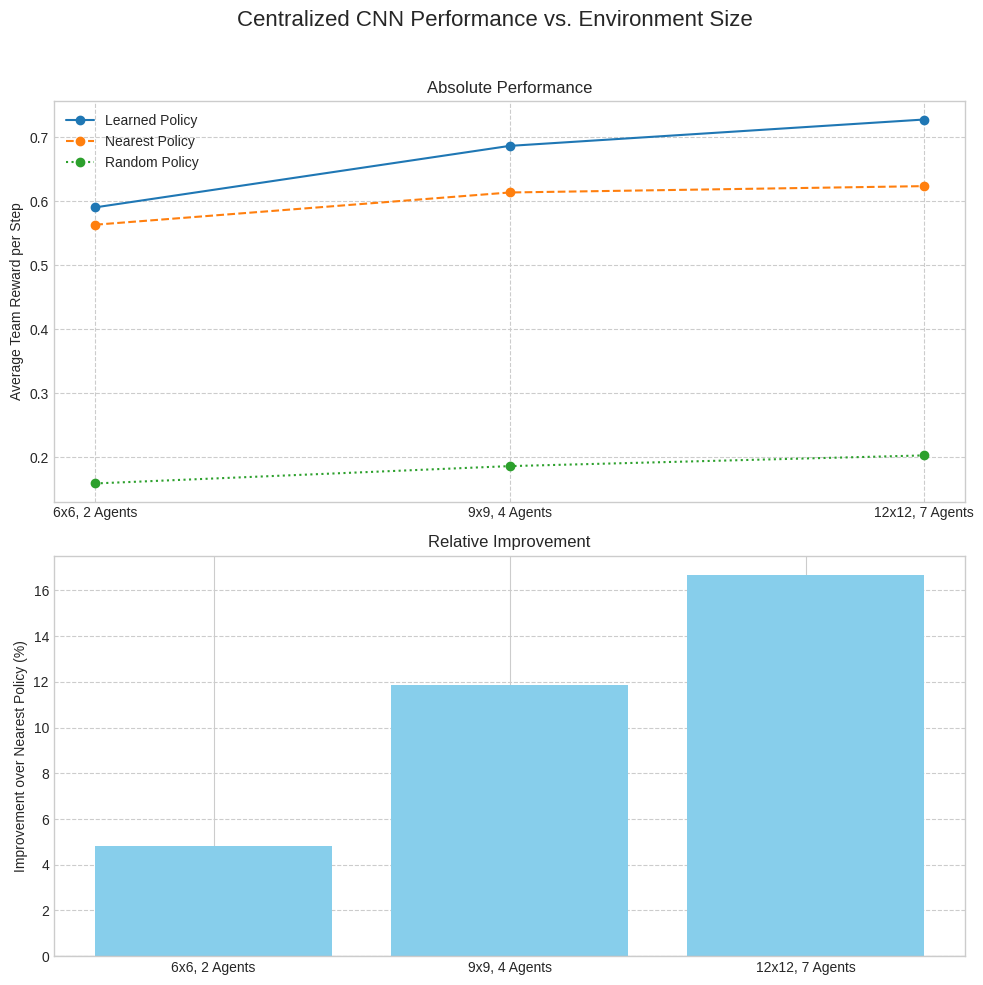

In [4]:
if not centralized_env_sizes.empty:
    # --- Data Preparation ---
    # Create a descriptive label for the x-axis
    centralized_env_sizes['env_label'] = centralized_env_sizes.apply(
        lambda row: f"{row['width']}x{row['height']}, {row['num_agents']} Agents", axis=1
    )
    # Sort by the number of agents to ensure a logical order on the x-axis
    centralized_env_sizes = centralized_env_sizes.sort_values(by='num_agents')
    
    # Calculate relative improvement over the nearest policy
    centralized_env_sizes['relative_improvement'] = (
        (centralized_env_sizes['mean_learned_reward'] - centralized_env_sizes['mean_nearest_reward']) /
         centralized_env_sizes['mean_nearest_reward']
    ) * 100  # As a percentage

    # --- Plotting ---
    fig, axs = plt.subplots(2, 1, figsize=(10, 10))
    fig.suptitle('Centralized CNN Performance vs. Environment Size', fontsize=16)

    # == Plot 1: Absolute Performance ==
    axs[0].plot(centralized_env_sizes['env_label'], centralized_env_sizes['mean_learned_reward'], marker='o', linestyle='-', label='Learned Policy')
    axs[0].plot(centralized_env_sizes['env_label'], centralized_env_sizes['mean_nearest_reward'], marker='o', linestyle='--', label='Nearest Policy')
    axs[0].plot(centralized_env_sizes['env_label'], centralized_env_sizes['mean_random_reward'], marker='o', linestyle=':', label='Random Policy')
    axs[0].set_ylabel('Average Team Reward per Step')
    axs[0].set_title('Absolute Performance')
    axs[0].legend()
    axs[0].grid(True, which='both', linestyle='--')

    # == Plot 2: Relative Improvement vs. Nearest Policy ==
    axs[1].bar(centralized_env_sizes['env_label'], centralized_env_sizes['relative_improvement'], color='skyblue')
    axs[1].axhline(0, color='grey', linewidth=0.8)
    axs[1].set_ylabel('Improvement over Nearest Policy (%)')
    axs[1].set_title('Relative Improvement')
    axs[1].grid(axis='y', linestyle='--')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
else:
    print("No centralized data found in 'results_env_sizes.csv' to plot.")

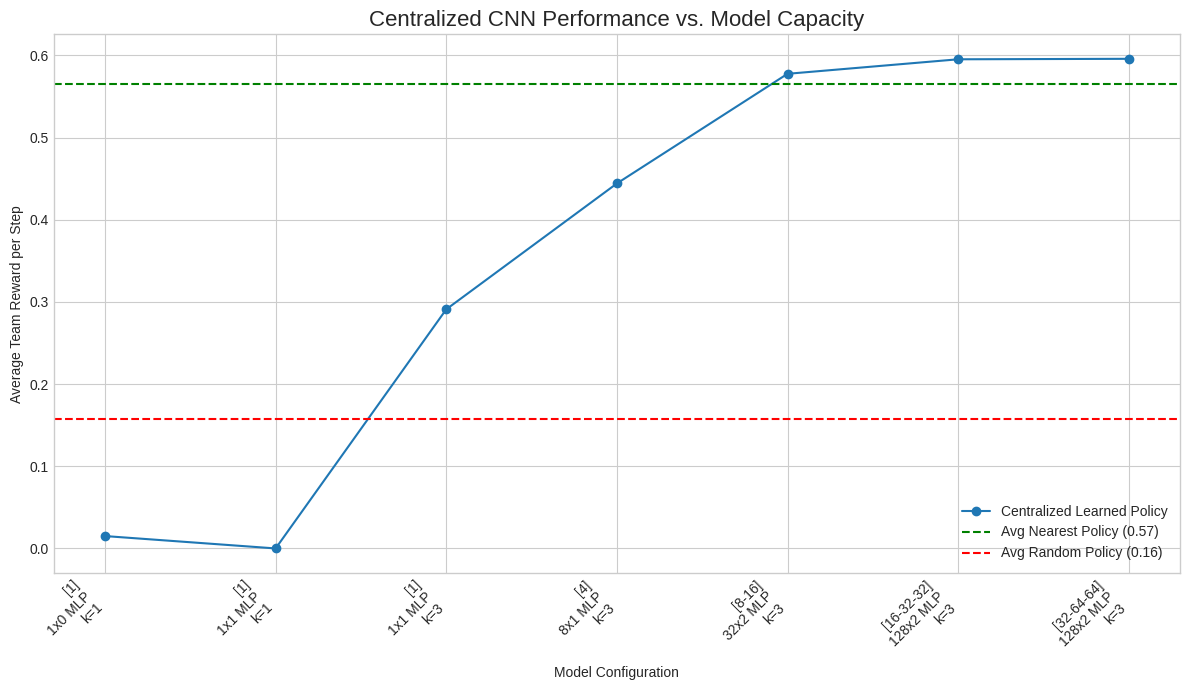

In [3]:
if not centralized_model_sizes.empty:
    # --- Data Preparation ---
    # Calculate a single, stable average for the baseline policies
    avg_random_reward = centralized_model_sizes['mean_random_reward'].mean()
    avg_nearest_reward = centralized_model_sizes['mean_nearest_reward'].mean()

    # Create a descriptive label for the x-axis
    centralized_model_sizes['model_label'] = centralized_model_sizes.apply(
        lambda row: f"[{row['conv_channels']}]\n{row['mlp_features']}x{row['mlp_layers']} MLP\nk={row['kernel_size']}",
        axis=1
    )
    
    # Define the logical order of the models from smallest to largest
    model_order = [
        "[1]\n1x0 MLP\nk=1",          # Point
        "[1]\n1x1 MLP\nk=1",          # Point+
        "[1]\n1x1 MLP\nk=3",          # Tiny
        "[4]\n8x1 MLP\nk=3",          # Tiny+
        "[8-16]\n32x2 MLP\nk=3",      # Small
        "[16-32-32]\n128x2 MLP\nk=3", # Medium
        "[32-64-64]\n128x2 MLP\nk=3"  # Large
    ]
    
    # Set the categorical order for the plot
    centralized_model_sizes['model_label'] = pd.Categorical(
        centralized_model_sizes['model_label'], categories=model_order, ordered=True
    )
    centralized_model_sizes = centralized_model_sizes.sort_values('model_label')

    # --- Plotting ---
    plt.figure(figsize=(12, 7))
    
    # Plot learned policy performance
    plt.plot(centralized_model_sizes['model_label'], centralized_model_sizes['mean_learned_reward'], marker='o', linestyle='-', label='Centralized Learned Policy')
    
    # Plot baseline policies as horizontal lines
    plt.axhline(avg_nearest_reward, color='green', linestyle='--', label=f'Avg Nearest Policy ({avg_nearest_reward:.2f})')
    plt.axhline(avg_random_reward, color='red', linestyle='--', label=f'Avg Random Policy ({avg_random_reward:.2f})')
    
    plt.title('Centralized CNN Performance vs. Model Capacity', fontsize=16)
    plt.xlabel('Model Configuration')
    plt.ylabel('Average Team Reward per Step')
    plt.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No centralized data found in 'results.csv' to plot.")